### Jonathan Steen
### MSDS, Bellevue University
### DSC 630: Predictive Analytics
### Instructor: Frank Neugebauer
### April 5th, 2025
### 4.2 Assignment: Clustering Exercise

## Step 1: Set Imports, Load Data and Initial Exploration

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load ALS data from CSV
als_df = pd.read_csv('/Volumes/Extreme Pro/Box Sync/School/DSC/DSC 630/Week 4/als_data.csv')

# Preview the first few rows to understand the structure and data types
als_df.head()

,ID,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,...,Sodium_min,Sodium_range,SubjectID,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,1,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,...,143.0,0.017422,533,8,7.0,7,0.002646,6.0,6.0,6.0
1,2,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,...,136.0,0.010453,649,8,7.0,5,0.005386,7.0,5.0,5.0
2,3,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,...,140.0,0.008929,1234,5,0.0,0,0.008929,6.0,5.0,5.0
3,4,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,...,138.0,0.012469,2492,5,5.0,3,0.004988,7.0,6.0,5.0
4,5,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,...,138.0,0.008292,2956,6,4.0,1,0.008489,6.0,5.0,5.0


In [32]:
# Get a list of all column names in the DataFrame
als_df.columns.tolist()

['ID',
 'Age_mean',
 'Albumin_max',
 'Albumin_median',
 'Albumin_min',
 'Albumin_range',
 'ALSFRS_slope',
 'ALSFRS_Total_max',
 'ALSFRS_Total_median',
 'ALSFRS_Total_min',
 'ALSFRS_Total_range',
 'ALT.SGPT._max',
 'ALT.SGPT._median',
 'ALT.SGPT._min',
 'ALT.SGPT._range',
 'AST.SGOT._max',
 'AST.SGOT._median',
 'AST.SGOT._min',
 'AST.SGOT._range',
 'Bicarbonate_max',
 'Bicarbonate_median',
 'Bicarbonate_min',
 'Bicarbonate_range',
 'Blood.Urea.Nitrogen..BUN._max',
 'Blood.Urea.Nitrogen..BUN._median',
 'Blood.Urea.Nitrogen..BUN._min',
 'Blood.Urea.Nitrogen..BUN._range',
 'bp_diastolic_max',
 'bp_diastolic_median',
 'bp_diastolic_min',
 'bp_diastolic_range',
 'bp_systolic_max',
 'bp_systolic_median',
 'bp_systolic_min',
 'bp_systolic_range',
 'Calcium_max',
 'Calcium_median',
 'Calcium_min',
 'Calcium_range',
 'Chloride_max',
 'Chloride_median',
 'Chloride_min',
 'Chloride_range',
 'Creatinine_max',
 'Creatinine_median',
 'Creatinine_min',
 'Creatinine_range',
 'Gender_mean',
 'Glucose_ma

In [33]:
# Select ALS-relevant features
als_relevant_cols = [
    'Age_mean', 'Gender_mean', 'ALSFRS_slope', 'ALSFRS_Total_max',
    'ALSFRS_Total_median', 'ALSFRS_Total_min', 'ALSFRS_Total_range',
    'hands_max', 'hands_median', 'hands_min', 'hands_range',
    'leg_max', 'leg_median', 'leg_min', 'leg_range',
    'mouth_max', 'mouth_median', 'mouth_min', 'mouth_range',
    'trunk_max', 'trunk_median', 'trunk_min', 'trunk_range',
    'respiratory_max', 'respiratory_median', 'respiratory_min', 'respiratory_range',
    'onset_delta_mean', 'onset_site_mean'
]

als_relevant_df = als_df[als_relevant_cols]

#### **Rationale**: I chose features related to ALS progression, motor function, and how the disease started. This includes ALS score data, body functions (like hands, legs, and breathing), and basics like age and gender. Focusing on these helps the clustering reflect patterns that matter for ALS.

## Step 2: Apply a Standard Scaler to the Data

In [34]:
# Standardize the features
scaler = StandardScaler()
als_scaled = scaler.fit_transform(als_relevant_df)

## Step 3: Create a Silhouette Score Plot

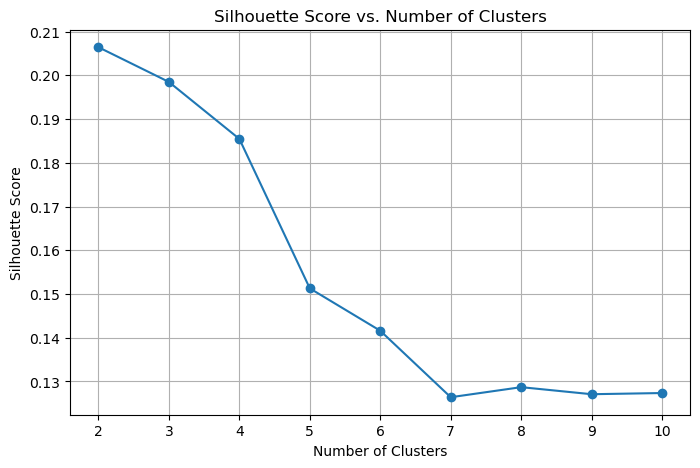

In [35]:
# Define the range of cluster numbers to evaluate
range_n_clusters = range(2, 11)
silhouette_scores = []

# Loop through each cluster count, fit K-means, and calculate silhouette score for different cluster values to evaluate how well each clustering configuration fits the data.
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(als_scaled)
    score = silhouette_score(als_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot silhouette scores for each number of clusters
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## Step 4: Choose Optimal Number of Clusters

In [36]:
# Based on the silhouette plot, I chose 3 clusters
optimal_clusters = 3

#### **Rationale**: Both 2 and 3 clusters had strong scores, but I chose 3 to get a bit more detail. Having an extra group might show small differences in how ALS affects patients that 2 clusters could miss. It adds a little complexity but could be more useful. Three clusters offer the best separation between patient groups in the data.

## Step 5: Fit K-Means Model with Optimal Clusters

In [37]:
# Fit K-means with 3 clusters
kmeans_final = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(als_scaled)

## Step 6: Apply PCA Transformation with Two Features

In [38]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
als_pca = pca.fit_transform(als_scaled)

## Step 7: Scatterplot of PCA-Transformed Data by Cluster

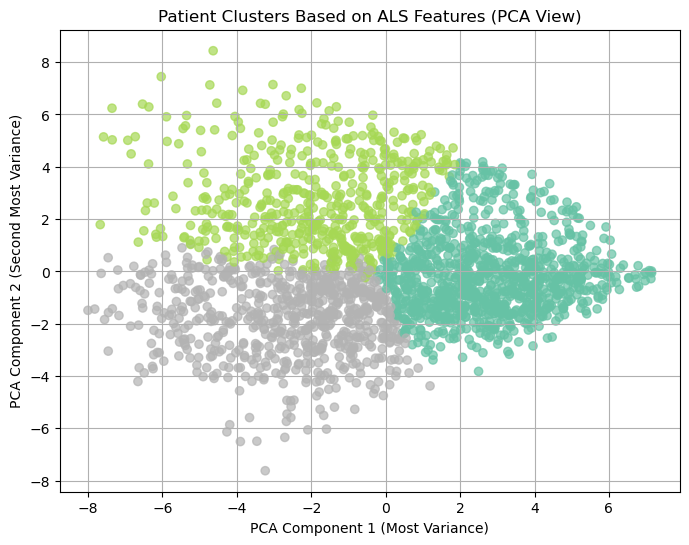

In [39]:
# Scatter plot of PCA results
plt.figure(figsize=(8, 6))
plt.scatter(als_pca[:, 0], als_pca[:, 1], c=cluster_labels_final, cmap='Set2', alpha=0.7)
plt.title('Patient Clusters Based on ALS Features (PCA View)')
plt.xlabel('PCA Component 1 (Most Variance)')
plt.ylabel('PCA Component 2 (Second Most Variance)')
plt.grid(True)
plt.show()

> The PCA scatterplot provides a visual confirmation of how distinct the clusters are based on ALS-related attributes.

## ALS Patient Clustering Conclusion

After cleaning and scaling the data, I explored clustering performance using silhouette scores and found 3 clusters to be optimal. I then used PCA to visualize the clustered data in two dimensions. The resulting plot showed reasonably distinct groupings, suggesting that K-means were effective in identifying different ALS subpopulations. From my perspective, these clusters may represent variations in patient progression or symptom presentation and could be explored further to inform treatment strategies.

## Key Findings:
- The data naturally formed three patient groups with different patterns in ALS scores and motor function.
- PCA made it easier to see the separation between clusters.
- Features like ALSFRS scores and limb function were key in forming the clusters.

## Recommendations:
- Look into what makes each group different—this could help with treatment planning.
- Use cluster-info to support decisions in clinical research or care.

## Limitations and Next Steps:

Since clustering is unsupervised, the meaning of each group isn’t guaranteed. Next steps could include:
- Adding more detailed clinical data,
- Trying other clustering methods,
- Comparing clusters to real-world outcomes like progression speed or survival.